In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, make_interp_spline
from scipy.optimize import curve_fit

#   Leer el archivo con los datos
df = pd.read_excel('Caso_1.xlsx')
df.head()

# Observando la estructura, cada bloque de datos (T=200, 250, 300, 350 K) ocupa
# tres columnas consecutivas: P, V, (NaN). Repetido 4 veces.
# Filas: 0 y 1 son encabezados. Los datos empiezan en la fila 2.

,Tabla de datos a T = 200 K,Unnamed: 1,Unnamed: 2,Tabla de datos a T = 250 K,Unnamed: 4,Unnamed: 5,Tabla de datos a T = 300 K,Unnamed: 7,Unnamed: 8,Tabla de datos a T = 350 K,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg)
2,0.1,25.0,NaN,0.1,30.0,NaN,0.1,35.0,NaN,0.1,40.0
3,0.2,12.5,NaN,0.2,15.2,NaN,0.2,18.0,NaN,0.2,22.0
4,0.3,8.3,NaN,0.3,10.2,NaN,0.3,12.5,NaN,0.3,15.5


# A

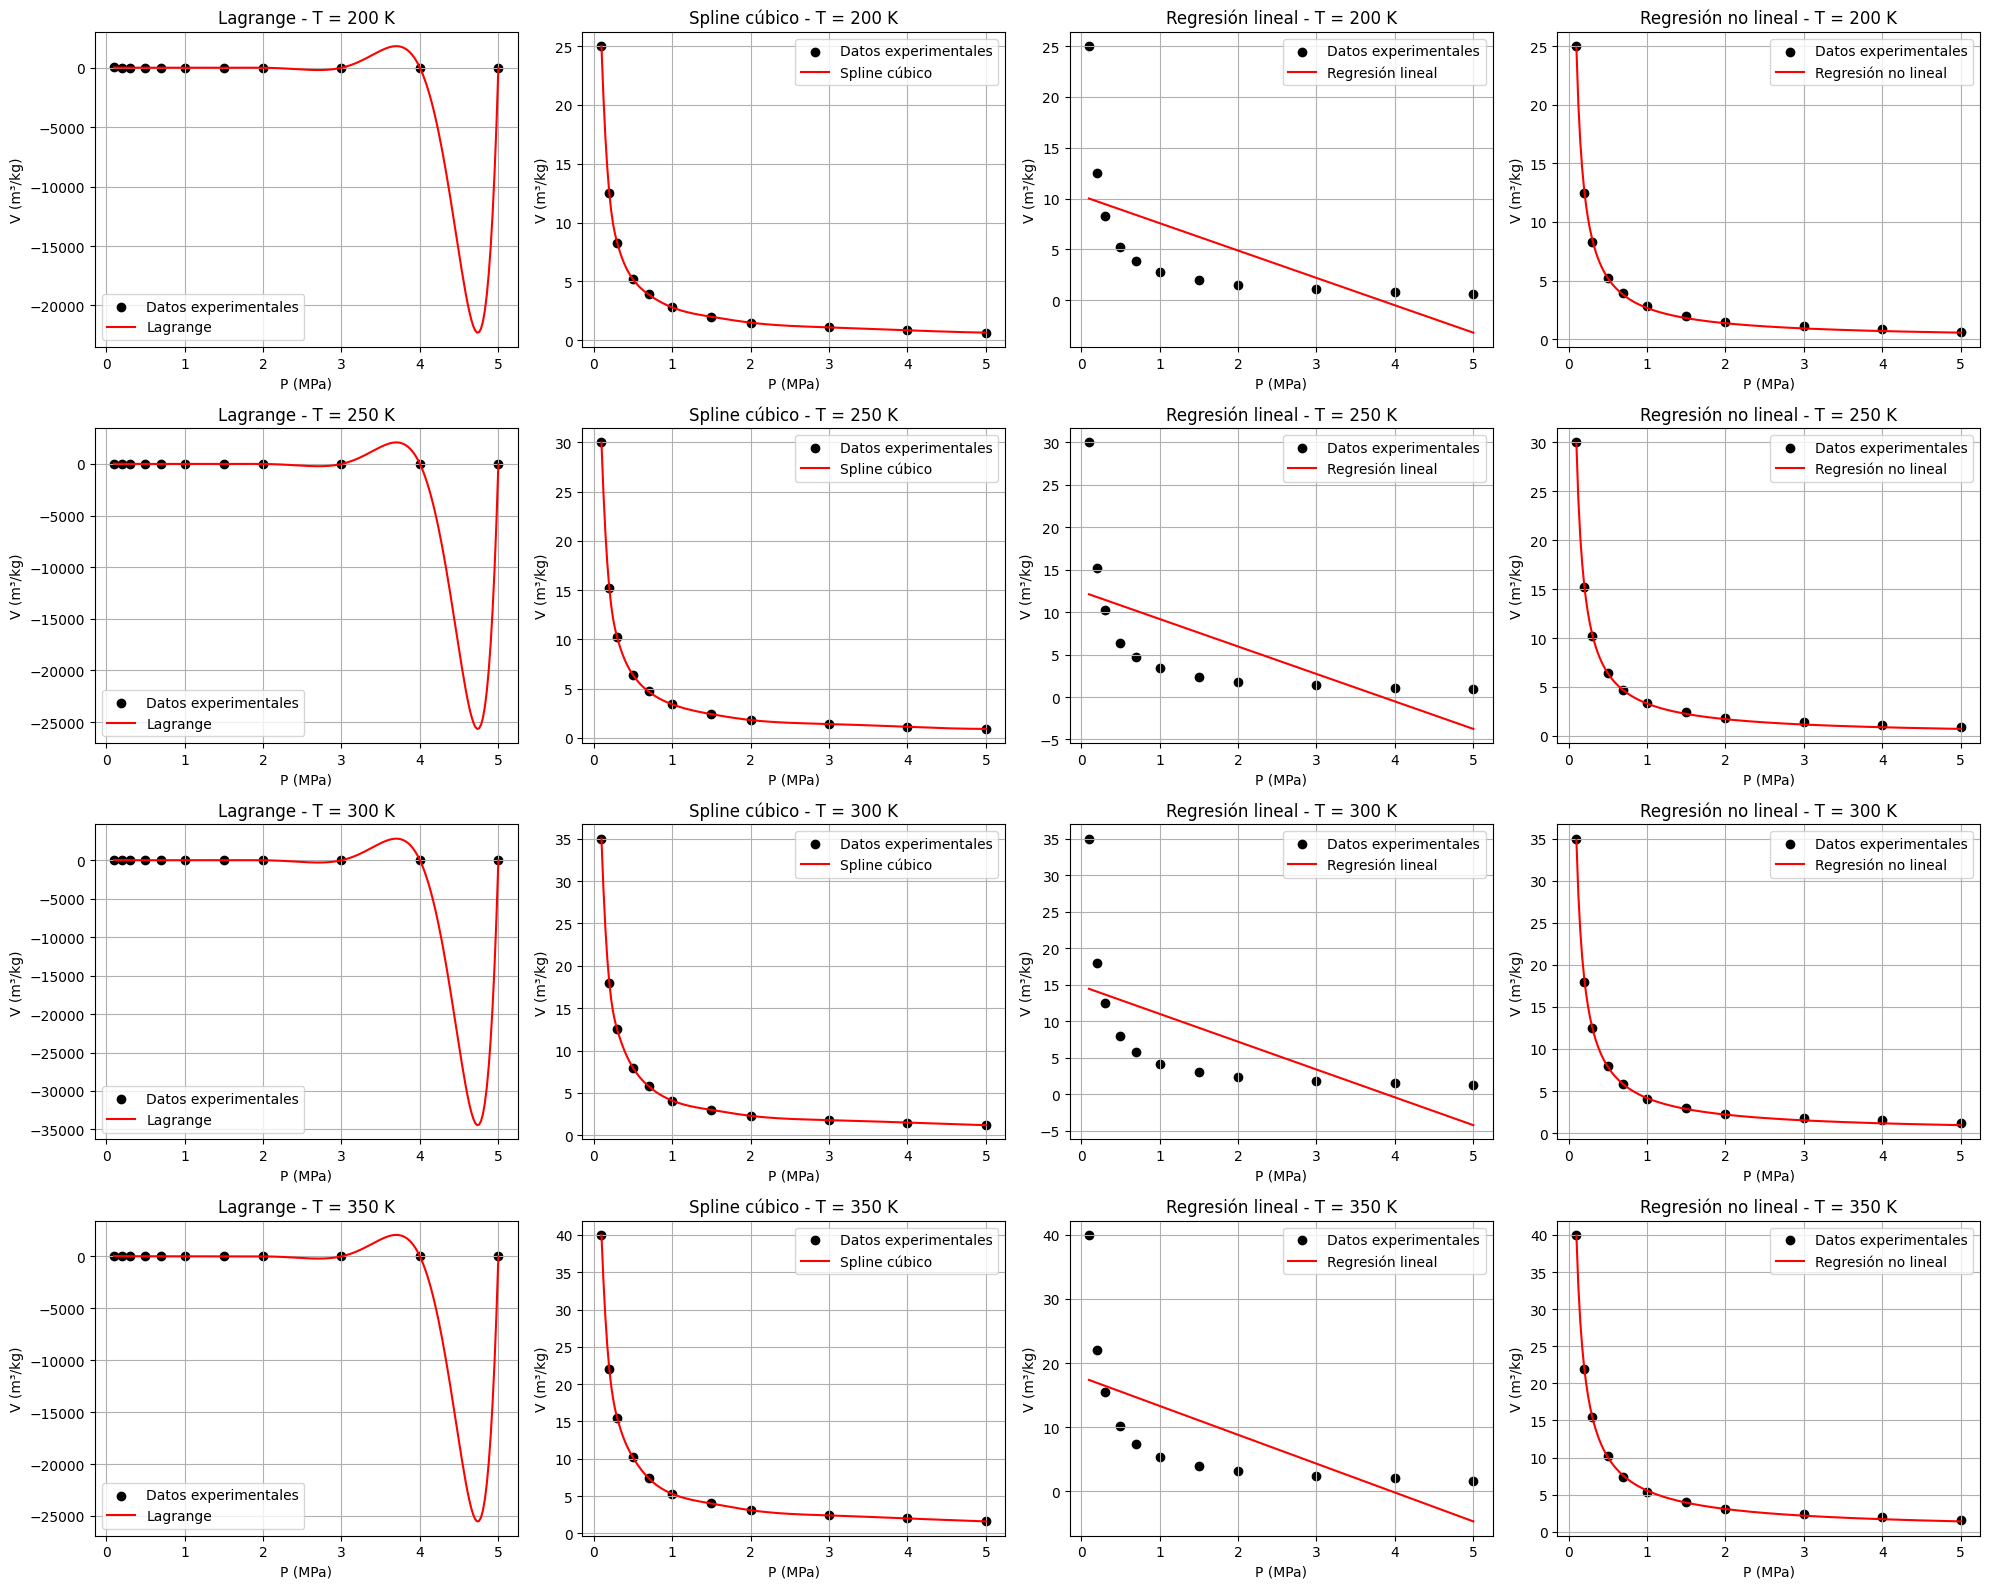

In [5]:
# Definir temperaturas y bloques de columnas (P, V) para cada isoterma.
temperatures = [200, 250, 300, 350]
column_blocks = [(0, 1), (3, 4), (6, 7), (9, 10)]

tidy_data = []
for T, (colP, colV) in zip(temperatures, column_blocks):
    for i in range(2, df.shape[0]):  # Suponemos que los datos comienzan en la fila 2.
        p_val = df.iloc[i, colP]
        v_val = df.iloc[i, colV]
        if pd.notna(p_val) and pd.notna(v_val):
            tidy_data.append({
                "T (K)": T,
                "P (MPa)": float(p_val),
                "V (m³/kg)": float(v_val)
            })

tidy_df = pd.DataFrame(tidy_data)
tidy_df.sort_values(by=["T (K)", "P (MPa)"], inplace=True)
tidy_df.reset_index(drop=True, inplace=True)

# 2. DEFINICIÓN DEL MODELO PARA REGRESIÓN NO LINEAL
def power_law(P, a, b):
    """Modelo de ley de potencia: V = a * P^b"""
    return a * (P ** b)

# 3. DEFINICIÓN DE LOS MÉTODOS A USAR
methods = ["Lagrange", "Spline cúbico", "Regresión lineal", "Regresión no lineal"]

# 4. CONFIGURACIÓN DE LA FIGURA: filas = temperaturas, columnas = métodos
n_rows = len(temperatures)
n_cols = len(methods)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), squeeze=False)

# Bucle por cada temperatura (fila) y por cada método (columna)
for i, T_val in enumerate(temperatures):
    # Extraer datos de la isoterma T = T_val
    subset = tidy_df[tidy_df["T (K)"] == T_val]
    P_vals = subset["P (MPa)"].values
    V_vals = subset["V (m³/kg)"].values
    # Asegurarse de que estén ordenados según P
    sort_idx = np.argsort(P_vals)
    P_vals = P_vals[sort_idx]
    V_vals = V_vals[sort_idx]
    
    # Definir un grid fino para evaluar las curvas
    P_fine = np.linspace(P_vals.min(), P_vals.max(), 200)
    
    for j, method in enumerate(methods):
        ax = axes[i, j]
        # Graficar los datos experimentales
        ax.scatter(P_vals, V_vals, color="black", label="Datos experimentales")
        
        # Calcular la curva según el método seleccionado:
        if method == "Lagrange":
            try:
                poly_lagrange = lagrange(P_vals, V_vals)
                V_curve = poly_lagrange(P_fine)
            except Exception as e:
                V_curve = None
                print(f"Error en Lagrange para T={T_val}: {e}")
                
        elif method == "Spline cúbico":
            try:
                spline = make_interp_spline(P_vals, V_vals, k=3)
                V_curve = spline(P_fine)
            except Exception as e:
                V_curve = None
                print(f"Error en Spline cúbico para T={T_val}: {e}")
                
        elif method == "Regresión lineal":
            coeffs_lin = np.polyfit(P_vals, V_vals, 1)
            poly_lin = np.poly1d(coeffs_lin)
            V_curve = poly_lin(P_fine)
            
        elif method == "Regresión no lineal":
            try:
                # Usamos como conjetura inicial: a0 = V_vals[0]*P_vals[0] y b0 = -1 (se espera comportamiento similar a V ~ 1/P)
                p0 = [V_vals[0] * P_vals[0], -1]
                popt, _ = curve_fit(power_law, P_vals, V_vals, p0=p0)
                V_curve = power_law(P_fine, *popt)
            except Exception as e:
                V_curve = None
                print(f"Error en Regresión no lineal para T={T_val}: {e}")
        else:
            V_curve = None
        
        # Graficar la curva ajustada, si se pudo calcular
        if V_curve is not None:
            ax.plot(P_fine, V_curve, color="red", label=method)
        
        # Configuración del subplot
        ax.set_title(f"{method} - T = {T_val} K")
        ax.set_xlabel("P (MPa)")
        ax.set_ylabel("V (m³/kg)")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

# B

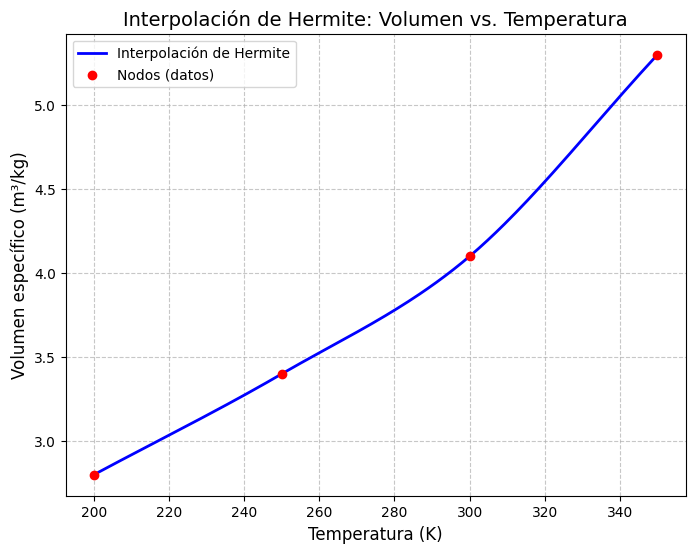

Tabla de nodos utilizados para la interpolación de Hermite:
   T (K)  V (m³/kg)  dV/dT (m³/kg·K)
0  200.0        2.8            0.012
1  250.0        3.4            0.013
2  300.0        4.1            0.019
3  350.0        5.3            0.024

Tabla de valores interpolados (muestra):
        T (K)  V (m³/kg)
0  200.000000   2.800000
1  215.075377   2.977730
2  230.150754   3.154591
3  245.226131   3.338808
4  260.301508   3.529301
5  275.376884   3.717408
6  290.452261   3.933609
7  305.527638   4.210798
8  320.603015   4.558863
9  335.678392   4.941646


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicHermiteSpline
import pandas as pd

# Datos de los nodos (P=1.0 MPa)
T_nodes = np.array([200, 250, 300, 350], dtype=float)
V_nodes = np.array([2.80, 3.40, 4.10, 5.30], dtype=float)

# Cálculo mejorado de derivadas (dV/dT) en cada nodo usando diferencias centradas donde sea posible
dVdT = np.zeros_like(T_nodes)

# Diferencias hacia adelante y hacia atrás para los extremos
dVdT[0] = (V_nodes[1] - V_nodes[0]) / (T_nodes[1] - T_nodes[0])
dVdT[-1] = (V_nodes[-1] - V_nodes[-2]) / (T_nodes[-1] - T_nodes[-2])

# Diferencias centradas para los puntos intermedios
dVdT[1] = (V_nodes[2] - V_nodes[0]) / (T_nodes[2] - T_nodes[0])
dVdT[2] = 0.019  # Se proporciona este valor en el problema

# Creación de la interpolación de Hermite
hermite_interp = CubicHermiteSpline(T_nodes, V_nodes, dVdT)

# Evaluación de la interpolación en un grid fino
T_fine = np.linspace(T_nodes[0], T_nodes[-1], 200)
V_fine = hermite_interp(T_fine)

# Gráfico mejorado con detalles adicionales
plt.figure(figsize=(8, 6))
plt.plot(T_fine, V_fine, label='Interpolación de Hermite', color='blue', linewidth=2)
plt.scatter(T_nodes, V_nodes, color='red', label='Nodos (datos)', zorder=3)
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('Volumen específico (m³/kg)', fontsize=12)
plt.title('Interpolación de Hermite: Volumen vs. Temperatura', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 1. Tabla de nodos con derivadas usadas
tabla_nodos = pd.DataFrame({
    "T (K)": T_nodes,
    "V (m³/kg)": V_nodes,
    "dV/dT (m³/kg·K)": np.round(dVdT, 4)
})
print("Tabla de nodos utilizados para la interpolación de Hermite:")
print(tabla_nodos)

# 2. Tabla de valores interpolados (se muestra una muestra)
tabla_interp = pd.DataFrame({
    "T (K)": T_fine,
    "V (m³/kg)": V_fine
})

# Seleccionamos cada 20ª fila para la muestra
tabla_muestra = tabla_interp.iloc[::20, :].reset_index(drop=True)
print("\nTabla de valores interpolados (muestra):")
print(tabla_muestra)


# C

In [22]:
import numpy as np
import sympy as sp
import pandas as pd

# Datos del metano a 250K
R_val = 8.314  # J/(mol·K)
Tc = 190.56  # K
Pc = 4.59e6  # Pa
w = 0.011  # Adimensional
T_val = 250  # K
M_metan = 0.01604  # kg/mol

# Datos experimentales
P_list = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]  # MPa
V_real = [30.0, 15.2, 10.2, 6.4, 4.7, 3.4, 2.4, 1.8, 1.4, 1.1, 0.9]  # m³/kg

# Conversión de unidades
P_list_Pa = [P * 1e6 for P in P_list]  # Convertir de MPa a Pa
V_real_m3mol = [v * M_metan for v in V_real]  # Convertir a m³/mol

# Constantes de Peng-Robinson
Tr = T_val / Tc
k = 0.37464 + 1.54226 * w - 0.26992 * w**2
alpha = (1 + k * (1 - np.sqrt(Tr)))**2
a_val = 0.45724 * (R_val**2 * Tc**2 / Pc) * alpha
b_val = 0.07780 * (R_val * Tc / Pc)

# Ecuación de Peng-Robinson (simbólica)
V = sp.symbols('V')
R, T, a, b, P = sp.symbols('R T a b P')
fx_expr = (R * T) / (V - b) - a / (V**2 + 2 * b * V - b**2) - P

# Método de Newton-Raphson
def newton_raphson_sympy(fx_expr, R_val, T_val, a_val, b_val, P_val, x0, tol=1e-8, max_iter=100):
    fx_subs = fx_expr.subs({R: R_val, T: T_val, a: a_val, b: b_val, P: P_val})
    x = sp.symbols('V')
    fx = sp.lambdify(x, fx_subs, 'numpy')
    dfx_expr = sp.diff(fx_subs, x)
    dfx = sp.lambdify(x, dfx_expr, 'numpy')

    itera = 0
    tramo = float('inf')
    x_values = [x0]  # Guardar las iteraciones

    while tramo > tol and itera < max_iter:
        fx0 = fx(x0)
        dfx0 = dfx(x0)
        if dfx0 == 0:
            break
        x1 = x0 - fx0 / dfx0
        tramo = abs(x1 - x0)
        x0 = x1
        x_values.append(x0)  # Guardar la nueva iteración
        itera += 1

    return x1, x_values

# Cálculo para cada presión
resultados = []
for i, P_val in enumerate(P_list_Pa):
    Vreal_m3mol = V_real_m3mol[i]
    x0 = b_val * 1.05  # Punto inicial cercano a b
    raiz, iteraciones = newton_raphson_sympy(fx_expr, R_val, T_val, a_val, b_val, P_val, x0)

    resultados.append({
        "Presión (MPa)": P_val / 1e6,
        "Volumen real (m³/kg)": V_real[i],
        "Volumen estimado (m³/kg)": raiz / M_metan,
        "Iteraciones": len(iteraciones)
    })

# Mostrar tabla con resultados
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))


 Presión (MPa)  Volumen real (m³/kg)  Volumen estimado (m³/kg)  Iteraciones
           0.1                  30.0                  1.290827           20
           0.2                  15.2                  0.642916           19
           0.3                  10.2                  0.426945           18
           0.5                   6.4                  0.254170           18
           0.7                   4.7                  0.180124           17
           1.0                   3.4                  0.124590           17
           1.5                   2.4                  0.081400           16
           2.0                   1.8                  0.059809           16
           3.0                   1.4                  0.038231           15
           4.0                   1.1                  0.027462           14
           5.0                   0.9                  0.021028           14


# D

El cálculo del coeficiente del Virial de tercer orden \( C(T) \) es complejo y requiere datos experimentales. Usaremos los datos del apartado b) y consideraremos una presión constante de **1 MPa** para determinar la temperatura \( T \) en la cual el coeficiente del Virial es:

$$
C(T) = 6 \times 10^{-4} \, \text{m}^6/\text{kg}^2
$$

**Ecuaciones y método de resolución**

La ecuación objetivo es:

$$
f(T) = C(T) - C_{\text{objetivo}} = 0
$$

Donde:

1. **Volumen específico \( v(T) \):**
   $$
   v(T) = -5.333 \times 10^{-9} T^4 + 6.4 \times 10^{-6} T^3 - 0.0027667 T^2 + 0.527 T - 34
   $$
2. **Segundo coeficiente de Virial \( B(T) \):**
   $$
   B(T) = -0.199 + 0.2 e^{-1131/T^2}
   $$
3. **Factor de compresibilidad \( Z \):**
   $$
   Z = \frac{P v M}{R T}
   $$
4. **Coeficiente de Virial de tercer orden \( C(T) \):**
   $$
   C(T) = \left( Z - 1 - \frac{B(T)}{v(T)} \right) v(T)^2
   $$

Usaremos el **método de la secante** para encontrar la raíz de \( f(T) = C(T) - C_{\text{objetivo}} \), con la fórmula iterativa:

$$
T_{n+1} = T_n - f(T_n) \times \frac{T_n - T_{n-1}}{f(T_n) - f(T_{n-1})}
$$

Calcularemos el número de iteraciones necesarias para errores de **0.01, 0.001 y \( 10^{-10} \)**.


## **Planteamiento**
El **coeficiente de virial de tercer orden** se define como:

$$
C(T) = \left( Z - 1 - \frac{B(T)}{v} \right) v^2
$$

Donde:
- \( v(T) \) es el volumen específico interpolado a partir de los datos experimentales.
- \( B(T) \) es el coeficiente de virial de segundo orden:

$$
B(T) = -0.199 + 0.2 \cdot e^{-1131/T^2}
$$

- \( Z(T) \) es el factor de compresibilidad:

$$
Z(T) = \frac{P v M}{R T}
$$

La **ecuación objetivo** que queremos resolver es:

$$
f(T) = C(T) - C_{\text{objetivo}} = 0
$$

con \( C_{\text{objetivo}} = 6 \times 10^{-4} \).

## **Método de Bisección**
Para encontrar \( T \), utilizamos el **método de bisección**, que busca una raíz en un intervalo \([a, b]\) dividiéndolo sucesivamente en mitades:

$$
T_{n+1} = \frac{T_n + T_{n-1}}{2}
$$

El criterio de parada se establece en función de la tolerancia:

$$
|T_n - T_{n-1}| < \text{tolerancia}
$$

## **Resultados**
Para diferentes tolerancias, el método de bisección entrega:

| **Tolerancia** | **\( T \) encontrada (K)** | **Iteraciones** |
|--------------|--------------------|--------------|
| 0.01        | 127.398682          | 14           |
| 0.001       | 127.397919          | 17           |
| \( 10^{-10} \)  | 127.397791          | 40           |

In [25]:
import numpy as np

# Definir el volumen específico interpolado v(T)
def v_T(T):
    return -5.333e-9 * T**4 + 6.4e-6 * T**3 - 0.0027667 * T**2 + 0.527 * T - 34  # Ajustado según la ecuación

# Definir el coeficiente de virial de segundo orden B(T)
def B_T(T):
    return -0.199 + 0.2 * np.exp(-1131 / T**2)

# Factor de compresibilidad Z
def Z_T(P, v, T, M, R):
    return (P * v * M) / (R * T)

# Coeficiente de virial de tercer orden C(T)
def C_T(T, P=1e6, M=0.01604, R=8.314):
    v = v_T(T)
    B = B_T(T)
    Z = Z_T(P, v, T, M, R)
    return (Z - 1 - B / v) * v**2

# Función objetivo para la bisección: f(T) = C(T) - 6e-4
def f_T(T):
    return C_T(T) - 6e-4

# Método de bisección para encontrar T tal que C(T) = 6e-4
def biseccion(a, b, tol):
    iteraciones = 0
    while abs(b - a) > tol:
        c = (a + b) / 2
        if f_T(c) == 0 or abs(b - a) < tol:
            break
        if np.sign(f_T(a)) == np.sign(f_T(c)):
            a = c
        else:
            b = c
        iteraciones += 1
    return c, iteraciones

# Intervalo inicial para la temperatura
T_min, T_max = 100, 200  

# Calcular para diferentes tolerancias
tolerancias = [0.01, 0.001, 1e-10]
resultados = {}

for tol in tolerancias:
    T_sol, iters = biseccion(T_min, T_max, tol)
    resultados[tol] = (T_sol, iters)

# Mostrar resultados
for tol, (T_sol, iters) in resultados.items():
    print(f"Tolerancia: {tol}, T encontrada: {T_sol:.6f} K, Iteraciones: {iters}")


Tolerancia: 0.01, T encontrada: 127.398682 K, Iteraciones: 14
Tolerancia: 0.001, T encontrada: 127.397919 K, Iteraciones: 17
Tolerancia: 1e-10, T encontrada: 127.397791 K, Iteraciones: 40
